<a href="https://colab.research.google.com/github/Oktavian19/PCVK_Ganjil_2025/blob/main/Week11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Object Detection
Metode yang digunakan
1. Template Matching
2. Edge Detection
3. Corner Detection
4. Grid Detection
5. Contour Detection

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## Template Matching

Menggunakan library openCV
**cv.matchTemplate()**, dengan parameter:
- **image**: citra input
- **templ**: template yang dicari, ukurannya tidak boleh lebih besar dari citra input
- **method**: metode dari template matching

Jenis metode template matching di OpenCV
1. TM_SODIFF
2. TM_SODIFF_NORMED
3. TM_CCORR
4. TM_CCORR_NORMED
5. TM_CCOEFF
6. TM_CCOEFF_NORMED

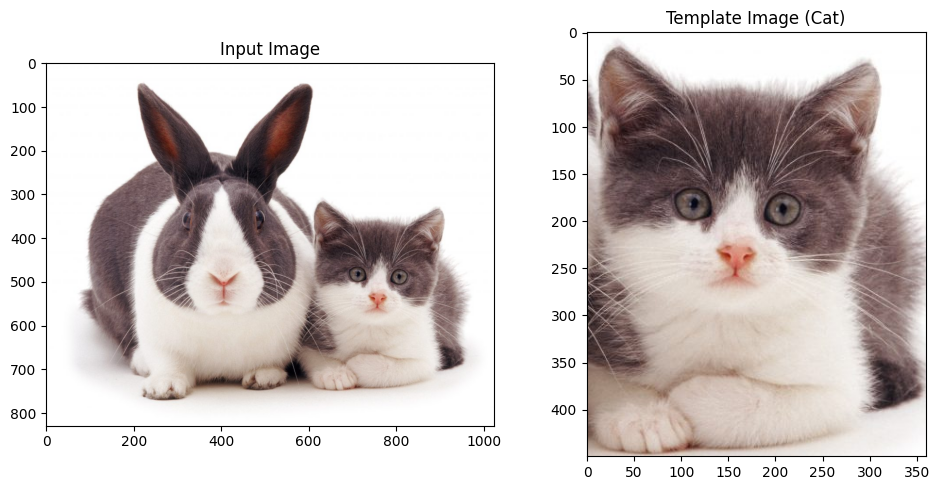

In [3]:
path = "/content/drive/MyDrive/asset/Images/Object Detection/cats_and_bunnies.jpg"
img = cv.imread(path)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

templ = img[300:750, 600:960]
w, h, c = templ.shape

plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Input Image")

plt.subplot(1, 2, 2)
plt.imshow(templ)
plt.title("Template Image (Cat)")

plt.tight_layout()
plt.show()

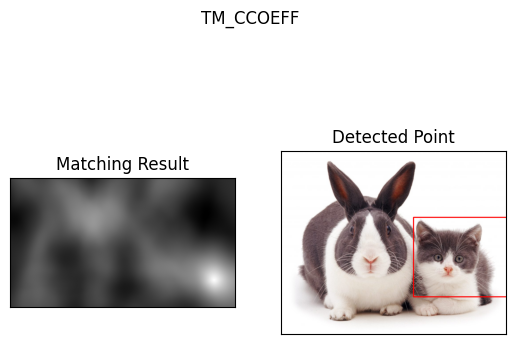

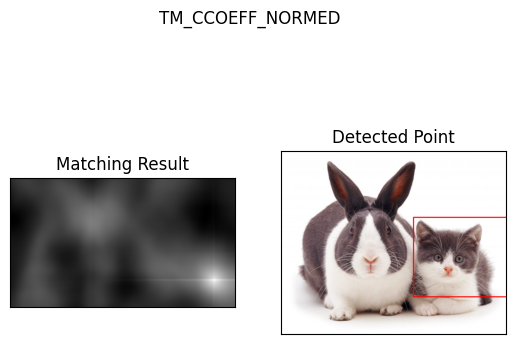

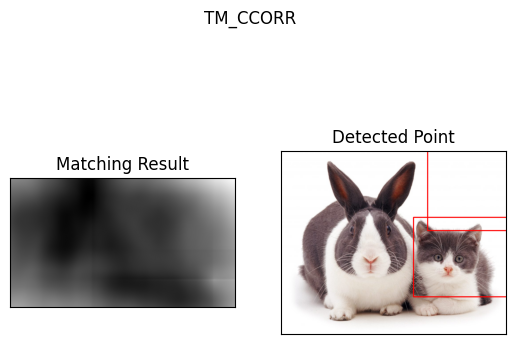

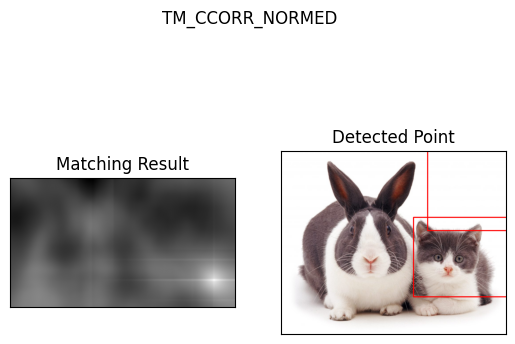

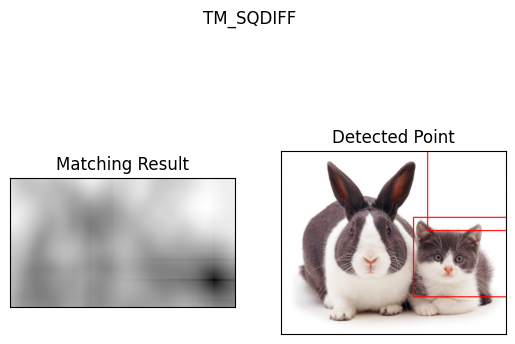

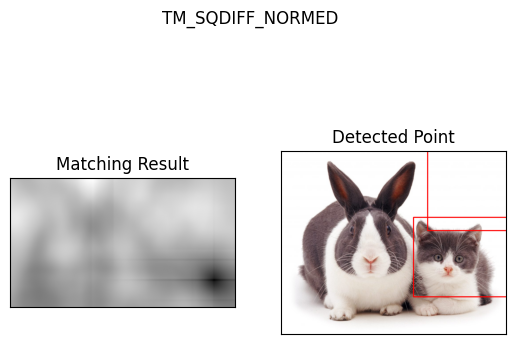

In [4]:
methods = ['TM_CCOEFF', 'TM_CCOEFF_NORMED', 'TM_CCORR',
            'TM_CCORR_NORMED', 'TM_SQDIFF', 'TM_SQDIFF_NORMED']

for meth in methods:
    method = getattr(cv, meth)

    # Apply template Matching
    res = cv.matchTemplate(img,templ,method)
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

    # If the method is TM_SQDIFF or TM_SQDIFF_NORMED, take minimum
    if method in [cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc
    bottom_right = (top_left[0] + w, top_left[1] + h)

    cv.rectangle(img,top_left, bottom_right, (255,0,0), 3)

    plt.subplot(121),plt.imshow(res,cmap = 'gray')
    plt.title('Matching Result'), plt.xticks([]), plt.yticks([])
    plt.subplot(122),plt.imshow(img,cmap = 'gray')
    plt.title('Detected Point'), plt.xticks([]), plt.yticks([])
    plt.suptitle(meth)

    plt.show()

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def create_rotated_templates(template, angles):
    """Membuat template yang dirotasi pada berbagai sudut"""
    rotated_templates = []
    template_pil = Image.fromarray(template)

    for angle in angles:
        rotated = template_pil.rotate(angle, expand=True, resample=Image.BICUBIC)
        rotated_array = np.array(rotated)
        rotated_templates.append((rotated_array, angle))

    return rotated_templates

def template_match_rotated(img, template, threshold=0.6):
    img_h, img_w = img.shape
    temp_h, temp_w = template.shape

    # Normalisasi
    template_mean = np.mean(template)
    template_std = np.std(template)
    template_norm = (template - template_mean) / (template_std + 1e-8)

    results = []

    # Sliding window
    for y in range(img_h - temp_h + 1):
        for x in range(img_w - temp_w + 1):
            window = img[y:y + temp_h, x:x + temp_w]

            if window.shape != template.shape:
                continue

            window_mean = np.mean(window)
            window_std = np.std(window)

            if window_std < 1e-8:
                continue

            window_norm = (window - window_mean) / window_std
            corr = np.mean(window_norm * template_norm)

            if corr >= threshold:
                results.append((x, y, corr))

    return results

def non_maximum_suppression(matches, min_distance=30):
    """Menghilangkan deteksi yang berdekatan"""
    if not matches:
        return []

    matches.sort(key=lambda x: x[2], reverse=True)

    suppressed = []

    for current_match in matches:
        x1, y1, score1 = current_match

        keep = True
        for kept_match in suppressed:
            x2, y2, score2 = kept_match
            distance = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

            if distance < min_distance:
                keep = False
                break

        if keep:
            suppressed.append(current_match)

    return suppressed

Melakukan template matching untuk berbagai rotasi...


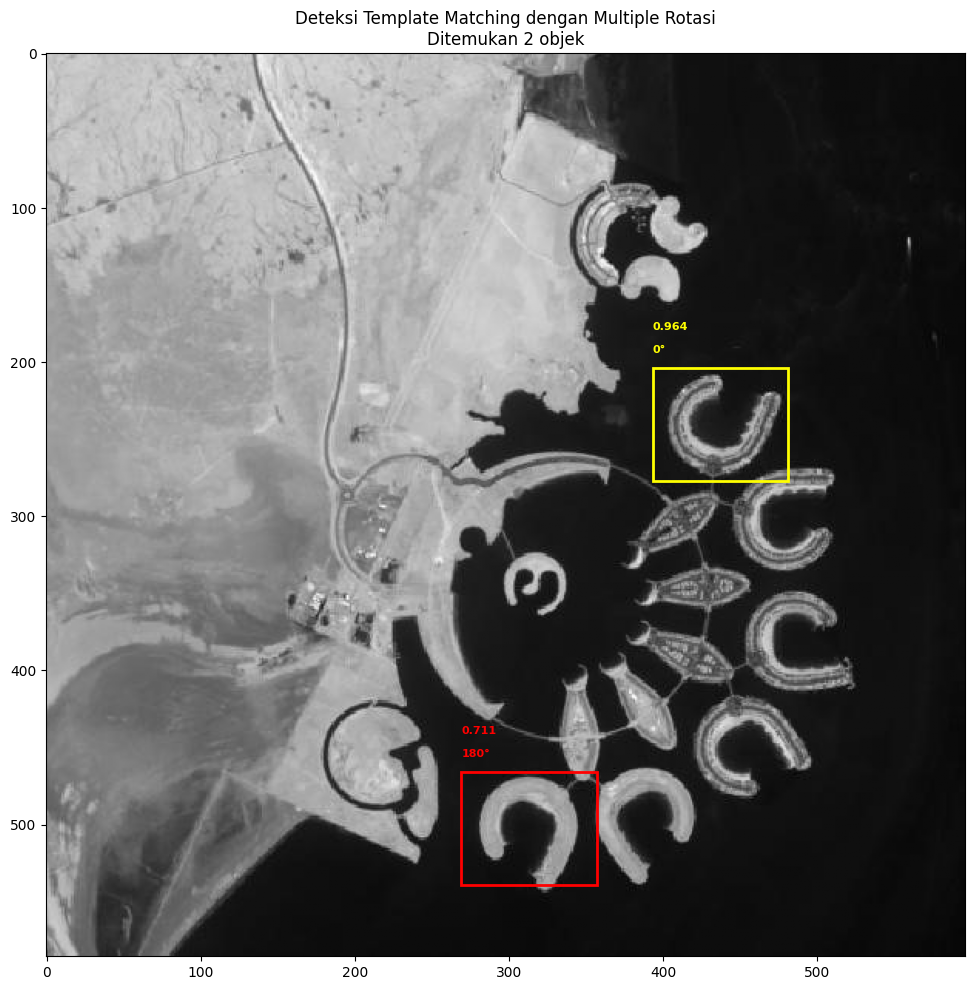

Total objek yang terdeteksi: 2
Objek 1: Posisi (393, 204), Rotasi 0°, Score: 0.964
Objek 2: Posisi (269, 466), Rotasi 180°, Score: 0.711


In [23]:
path = "/content/drive/MyDrive/asset/Images/Object Detection/bahrain.jpg"
template_path = "/content/drive/MyDrive/asset/Images/Object Detection/bahrain-template.jpg"

input_img = np.array(Image.open(path).convert("L"))
template_img = np.array(Image.open(template_path).convert("L"))

rotation_angles = [0, 90, 120, 180, 240, 300]

rotated_templates = create_rotated_templates(template_img, rotation_angles)

all_matches = []

print("Melakukan template matching untuk berbagai rotasi...")
for template_rotated, angle in rotated_templates:
    matches = template_match_rotated(input_img, template_rotated, threshold=0.6)

    for match in matches:
        x, y, score = match
        all_matches.append({
            'x': x,
            'y': y,
            'score': score,
            'angle': angle,
            'template_width': template_rotated.shape[1],
            'template_height': template_rotated.shape[0]
        })

matches_for_nms = [(m['x'], m['y'], m['score']) for m in all_matches]
filtered_matches = non_maximum_suppression(matches_for_nms, min_distance=50)

final_detections = []
for match in filtered_matches:
    x, y, score = match
    for original_match in all_matches:
        if (original_match['x'] == x and
            original_match['y'] == y and
            abs(original_match['score'] - score) < 0.001):
            final_detections.append(original_match)
            break

plt.figure(figsize=(12, 10))
plt.imshow(input_img, cmap="gray")

colors = ['yellow', 'red', 'green', 'blue', 'orange', 'purple']
color_idx = 0

for detection in final_detections:
    x = detection['x']
    y = detection['y']
    width = detection['template_width']
    height = detection['template_height']
    angle = detection['angle']
    score = detection['score']

    color = colors[color_idx % len(colors)]
    color_idx += 1

    rect = plt.Rectangle((x, y), width, height,
                         edgecolor=color, facecolor='none', linewidth=2)
    plt.gca().add_patch(rect)

    plt.text(x, y-10, f"{angle}°", color=color, fontsize=8, weight='bold')
    plt.text(x, y-25, f"{score:.3f}", color=color, fontsize=8, weight='bold')

plt.title(f"Deteksi Template Matching dengan Multiple Rotasi\nDitemukan {len(final_detections)} objek")
plt.tight_layout()
plt.show()

print(f"Total objek yang terdeteksi: {len(final_detections)}")
for i, det in enumerate(final_detections):
    print(f"Objek {i+1}: Posisi ({det['x']}, {det['y']}), Rotasi {det['angle']}°, Score: {det['score']:.3f}")

In [7]:
img = cv.imread('/content/drive/MyDrive/asset/Images/Object Detection/car-park.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

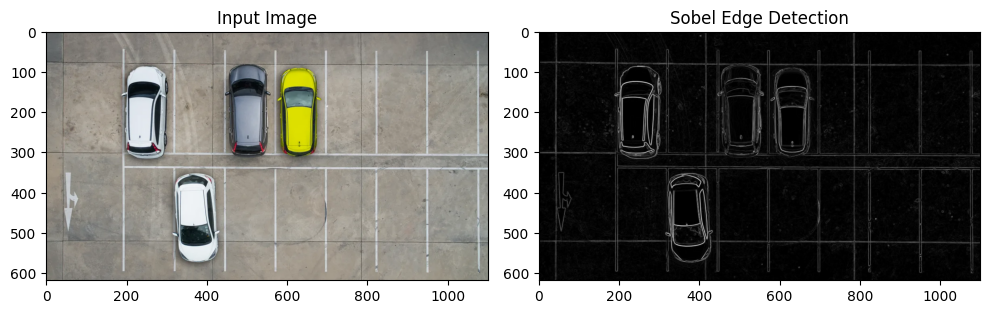

In [8]:
sobelx = cv.Sobel(gray, cv.CV_64F, 1, 0, ksize=3)
sobely = cv.Sobel(gray, cv.CV_64F, 0, 1, ksize=3)
sobel = cv.magnitude(sobelx, sobely)

plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Input Image")

plt.subplot(1, 2, 2)
plt.imshow(sobel, cmap = "gray")
plt.title("Sobel Edge Detection")

plt.tight_layout()
plt.show()

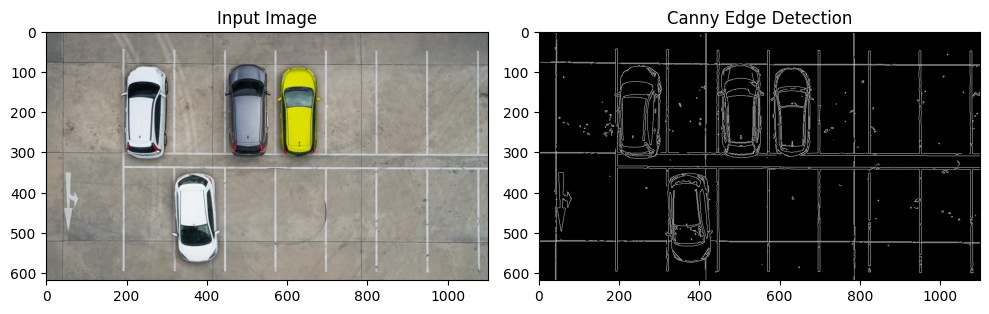

In [9]:
canny = cv.Canny(gray, 100, 200)

plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Input Image")

plt.subplot(1, 2, 2)
plt.imshow(canny, cmap = "gray")
plt.title("Canny Edge Detection")

plt.tight_layout()
plt.show()

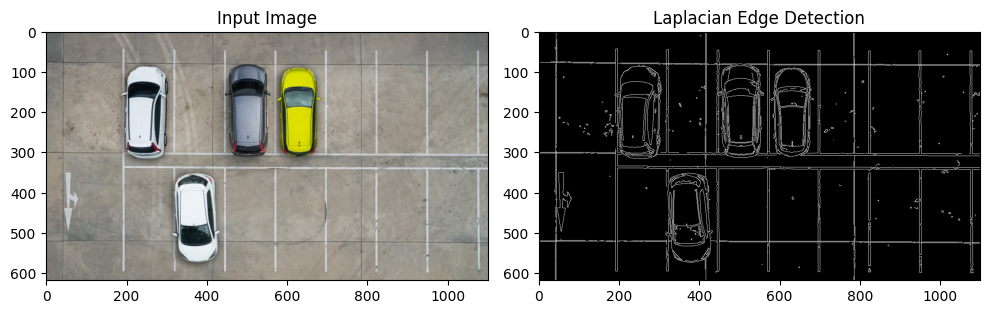

In [10]:
laplacian = cv.Laplacian(gray, cv.CV_64F)
laplacian = np.uint8(np.absolute(laplacian))

plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Input Image")

plt.subplot(1, 2, 2)
plt.imshow(canny, cmap = "gray")
plt.title("Laplacian Edge Detection")

plt.tight_layout()
plt.show()

In [17]:
def corner_detection_comparison_advanced(image_path, harris_params=None, shi_tomasi_params=None):
    """
    Fungsi advanced untuk membandingkan Harris Corner dan Shi-Tomasi Detection

    Parameters:
    - image_path: path ke gambar
    - harris_params: dict parameter untuk Harris
    - shi_tomasi_params: dict parameter untuk Shi-Tomasi
    """

    # Default parameters
    if harris_params is None:
        harris_params = {'blockSize': 2, 'ksize': 3, 'k': 0.04, 'threshold': 0.01}

    if shi_tomasi_params is None:
        shi_tomasi_params = {'maxCorners': 100, 'qualityLevel': 0.01, 'minDistance': 10}

    # Baca gambar
    img = cv.imread(image_path)
    if img is None:
        print(f"Error: Tidak dapat membaca gambar dari {image_path}")
        return None, None

    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # Harris Corner Detection
    gray_harris = np.float32(gray)
    dst = cv.cornerHarris(gray_harris,
                          blockSize=harris_params['blockSize'],
                          ksize=harris_params['ksize'],
                          k=harris_params['k'])
    dst = cv.dilate(dst, None)

    img_harris = img.copy()
    thresh_harris = harris_params['threshold'] * dst.max()
    img_harris[dst > thresh_harris] = [0, 0, 255]

    # Shi-Tomasi Detection
    corners = cv.goodFeaturesToTrack(gray,
                                     maxCorners=shi_tomasi_params['maxCorners'],
                                     qualityLevel=shi_tomasi_params['qualityLevel'],
                                     minDistance=shi_tomasi_params['minDistance'])

    img_shi_tomasi = img.copy()
    if corners is not None:
        corners = corners.astype(int)
        for corner in corners:
            x, y = corner.ravel()
            cv.circle(img_shi_tomasi, (x, y), 3, [0, 255, 0], -1)

    return img_harris, img_shi_tomasi

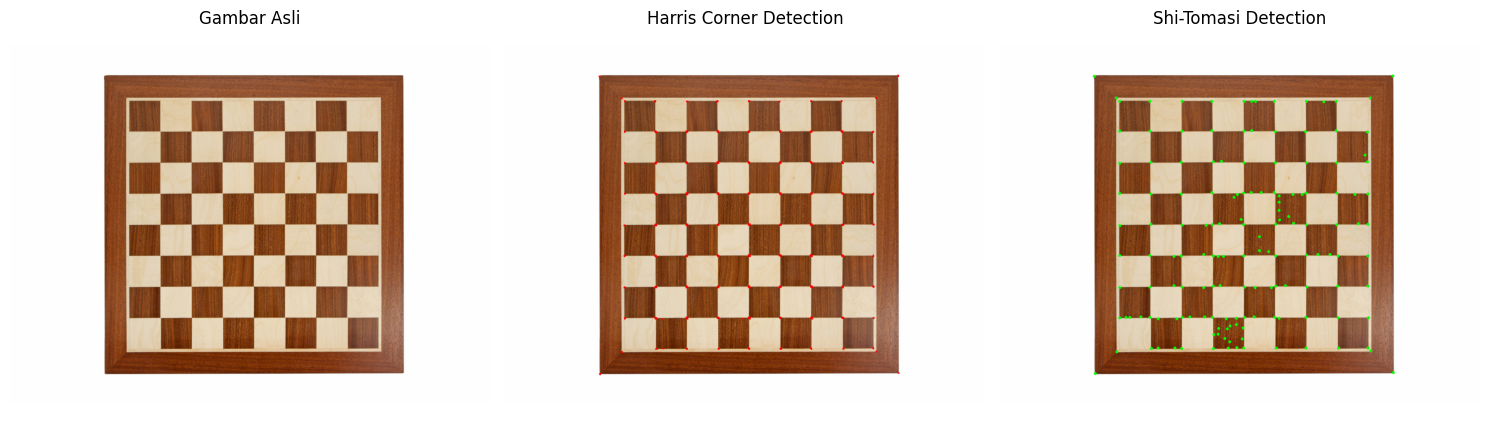

In [21]:
# Contoh penggunaan dengan parameter custom
path = '/content/drive/MyDrive/asset/Images/Object Detection/chess-board.jpg'
img = cv.imread(path)

# Custom parameters
harris_params = {'blockSize': 2, 'ksize': 3, 'k': 0.04, 'threshold': 0.01}
shi_tomasi_params = {'maxCorners': 150, 'qualityLevel': 0.01, 'minDistance': 8}

img_harris, img_shi_tomasi = corner_detection_comparison_advanced(
    path,
    harris_params=harris_params,
    shi_tomasi_params=shi_tomasi_params
)

# Visualisasi
plt.figure(figsize=(15, 5))

images = [
    (img, 'Gambar Asli'),
    (img_harris, 'Harris Corner Detection'),
    (img_shi_tomasi, 'Shi-Tomasi Detection')
]

for i, (image, title) in enumerate(images):
    plt.subplot(1, 3, i+1)
    plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()

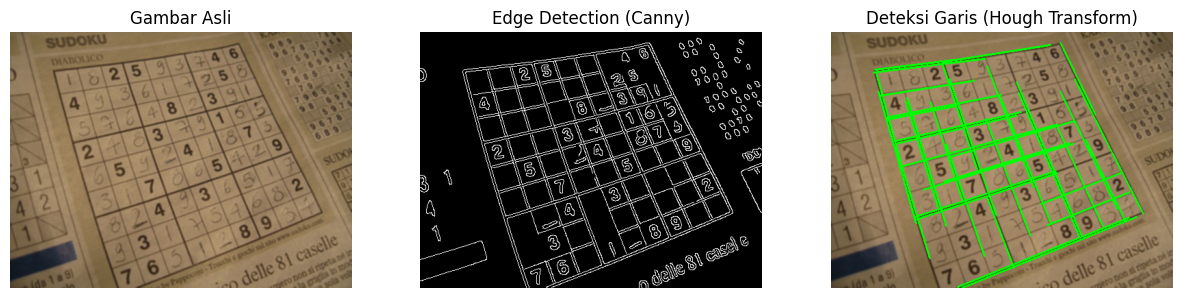

Jumlah garis terdeteksi: 38


In [29]:
path = "/content/drive/MyDrive/asset/Images/Object Detection/sudoku.jpg"
img = cv.imread(path)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(gray, (5, 5), 0)

edges = cv.Canny(blur, 50, 150, apertureSize=3)

lines = cv.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=100,
    minLineLength=100,
    maxLineGap=10
)

img_lines = img.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv.line(img_lines, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Gambar Asli")
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Edge Detection (Canny)")
plt.imshow(edges, cmap='gray')
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Deteksi Garis (Hough Transform)")
plt.imshow(cv.cvtColor(img_lines, cv.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

if lines is not None:
    print(f"Jumlah garis terdeteksi: {len(lines)}")
else:
    print("Tidak ada garis terdeteksi.")


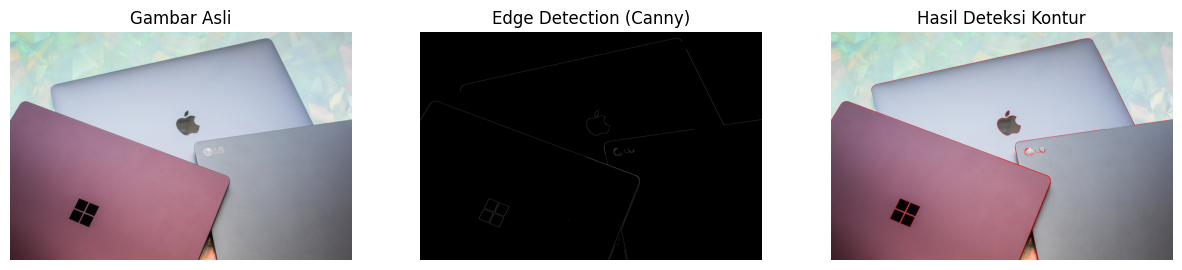

Jumlah kontur terdeteksi: 24


In [28]:
path = "/content/drive/MyDrive/asset/Images/Object Detection/laptop.jpg"
img = cv.imread(path)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(gray, (5, 5), 0)
edges = cv.Canny(blur, 100, 200)

contours, hierarchy = cv.findContours(edges, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

img_contours = img.copy()
cv.drawContours(img_contours, contours, -1, (0, 0, 255), 2)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Gambar Asli")
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Edge Detection (Canny)")
plt.imshow(edges, cmap='gray')
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Hasil Deteksi Kontur")
plt.imshow(cv.cvtColor(img_contours, cv.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

print(f"Jumlah kontur terdeteksi: {len(contours)}")
